In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
import lime
import lime.lime_tabular
import tensorflow as tf
from numpy.random import seed
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, LSTM, Bidirectional, GRU
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
seed(1)
tf.compat.v1.disable_v2_behavior()

data_DailyActivity = pd.read_csv("C:\\Users\\Rafael Oliveira\\Desktop\\Fitabase Data 4.12.16-5.12.16\\DailyActivityMesmoComOPeso.csv")

data_Peso = pd.read_csv("C:\\Users\\Rafael Oliveira\\Desktop\\Fitabase Data 4.12.16-5.12.16\\weightLogInfo_merged.csv")

def create_dataset_t(dataset, look_back, out, min, max):
    dataX, dataY = [], []
    for i in range(look_back, len(dataset)-look_back):
        a = dataset[i, :]
        if i+1<dataset.shape[0]:
            if np.all(np.isclose(dataset[(i-look_back):i, 0], dataset[(i-look_back), 0])):
                a = np.copy(dataset[(i-look_back):i, :])
                b = np.copy(dataset[(i-look_back):i, :])
                val_max = a[-1][1] * (max - min) + min
                for i in range(look_back):
                    valor_nor = a[i][1] * (max - min) + min
                    novo_valor = val_max - valor_nor
                    novo_valor_nor = (novo_valor - min) / (max - min)
                    b[i][1] = novo_valor_nor
                dataX.append(b)
                dataY.append(dataset[i+1, out])
    return np.array(dataX), np.array(dataY)

data_DailyActivity = data_DailyActivity.rename(columns={'ActivityDate': 'Date'})
data_DailyActivity['Date'] = pd.to_datetime(data_DailyActivity['Date'], format='%m/%d/%Y').dt.date

#Converter a coluna Date para o mesmo formato
data_Peso['Date'] = pd.to_datetime(data_Peso['Date'], format='%m/%d/%Y %H:%M:%S').dt.date

all_Data = pd.merge(data_DailyActivity, data_Peso, on=['Id', 'Date'])

id = '0'
data = None
for i in range(len(all_Data)):
    if all_Data.iloc[i, all_Data.columns.get_loc('Id')]!=id:
        id = all_Data.iloc[i, all_Data.columns.get_loc('Id')]
        data = all_Data.iloc[i, all_Data.columns.get_loc('Date')]
    diferenca = all_Data.loc[i, 'Date'] - data
    all_Data.loc[i, 'Date'] = diferenca.days
    
all_Data=all_Data.drop('Fat', axis=1)
all_Data=all_Data.drop('LogId', axis=1)
all_Data=all_Data.drop('IsManualReport', axis=1)
all_Data=all_Data.drop('WeightPounds', axis=1)

bmi_min = round(all_Data['BMI'].min(), 2)
bmi_max = round(all_Data['BMI'].max(), 2)
date_min = all_Data['Date'].min()
date_max = all_Data['Date'].max()
totalsteps_min = all_Data['TotalSteps'].min()
totalsteps_max = all_Data['TotalSteps'].max()
totaldistance_min = round(all_Data['TotalDistance'].min(), 2)
totaldistance_max = round(all_Data['TotalDistance'].max(), 2)
trackerdistance_min = round(all_Data['TrackerDistance'].min(), 2)
trackerdistance_max = round(all_Data['TrackerDistance'].max(), 2)
loggedactivitiesdistance_min = round(all_Data['LoggedActivitiesDistance'].min(), 2)
loggedactivitiesdistance_max = round(all_Data['LoggedActivitiesDistance'].max(), 2)
veryactivedistance_min = round(all_Data['VeryActiveDistance'].min(), 2)
veryactivedistance_max = round(all_Data['VeryActiveDistance'].max(), 2)
moderatelyactivedistance_min = round(all_Data['ModeratelyActiveDistance'].min(), 2)
moderatelyactivedistance_max = round(all_Data['ModeratelyActiveDistance'].max(), 2)
lightactivedistance_min = round(all_Data['LightActiveDistance'].min(), 2)
lightactivedistance_max = round(all_Data['LightActiveDistance'].max(), 2)
sedentaryactivedistance_min = round(all_Data['SedentaryActiveDistance'].min(), 2)
sedentaryactivedistance_max = round(all_Data['SedentaryActiveDistance'].max(), 2)
veryactiveminutes_min = all_Data['VeryActiveMinutes'].min()
veryactiveminutes_max = all_Data['VeryActiveMinutes'].max()
fairlyactiveminutes_min = all_Data['FairlyActiveMinutes'].min()
fairlyactiveminutes_max = all_Data['FairlyActiveMinutes'].max()
lightlyactiveminutes_min = all_Data['LightlyActiveMinutes'].min()
lightlyactiveminutes_max = all_Data['LightlyActiveMinutes'].max()
sedentaryminutes_min = all_Data['SedentaryMinutes'].min()
sedentaryminutes_max = all_Data['SedentaryMinutes'].max()
calories_min = all_Data['Calories'].min()
calories_max = all_Data['Calories'].max()
weightkg_min = round(all_Data['WeightKg'].min(), 2)
weightkg_max = round(all_Data['WeightKg'].max(), 2)

data = all_Data.values
dataset = data.astype('float32')

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

train_size = int(len(dataset) * 0.55)
test_size = len(dataset) - train_size
test = dataset[train_size:len(dataset),:]
train = dataset[0:train_size,:]
train_size = int(len(dataset))
train = dataset[0:train_size,:]

look_back = 3
trainX, trainY = create_dataset_t(train, look_back, 16, date_min, date_max)
testX, testY = create_dataset_t(test, look_back, 16, date_min, date_max)
trainX = trainX[:,:,1:]
testX = testX[:,:,1:]
all_Data=all_Data.drop('Id', axis=1)

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
model = Sequential()
model.add(LSTM(75, input_shape=(look_back,trainX.shape[2])))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [3]:
for i in range(5):
    model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

Train on 50 samples
Epoch 1/100
50/50 - 1s - loss: 0.0010 - 515ms/epoch - 10ms/sample
Epoch 2/100
50/50 - 0s - loss: 6.6778e-04 - 104ms/epoch - 2ms/sample
Epoch 3/100
50/50 - 0s - loss: 2.7825e-04 - 105ms/epoch - 2ms/sample
Epoch 4/100
50/50 - 0s - loss: 5.7281e-05 - 117ms/epoch - 2ms/sample
Epoch 5/100
50/50 - 0s - loss: 7.9335e-05 - 113ms/epoch - 2ms/sample
Epoch 6/100
50/50 - 0s - loss: 2.2547e-04 - 125ms/epoch - 2ms/sample
Epoch 7/100
50/50 - 0s - loss: 2.1905e-04 - 129ms/epoch - 3ms/sample
Epoch 8/100
50/50 - 0s - loss: 8.2381e-05 - 136ms/epoch - 3ms/sample
Epoch 9/100
50/50 - 0s - loss: 1.0204e-04 - 114ms/epoch - 2ms/sample
Epoch 10/100
50/50 - 0s - loss: 7.5897e-05 - 114ms/epoch - 2ms/sample
Epoch 11/100
50/50 - 0s - loss: 2.3758e-05 - 109ms/epoch - 2ms/sample
Epoch 12/100
50/50 - 0s - loss: 2.7772e-05 - 105ms/epoch - 2ms/sample
Epoch 13/100
50/50 - 0s - loss: 2.4025e-05 - 107ms/epoch - 2ms/sample
Epoch 14/100
50/50 - 0s - loss: 1.0832e-05 - 97ms/epoch - 2ms/sample
Epoch 15/100


Epoch 19/100
50/50 - 0s - loss: 6.3291e-06 - 96ms/epoch - 2ms/sample
Epoch 20/100
50/50 - 0s - loss: 3.0034e-06 - 97ms/epoch - 2ms/sample
Epoch 21/100
50/50 - 0s - loss: 7.8414e-07 - 94ms/epoch - 2ms/sample
Epoch 22/100
50/50 - 0s - loss: 9.5818e-07 - 95ms/epoch - 2ms/sample
Epoch 23/100
50/50 - 0s - loss: 6.0255e-07 - 96ms/epoch - 2ms/sample
Epoch 24/100
50/50 - 0s - loss: 1.5899e-06 - 97ms/epoch - 2ms/sample
Epoch 25/100
50/50 - 0s - loss: 5.0902e-06 - 93ms/epoch - 2ms/sample
Epoch 26/100
50/50 - 0s - loss: 2.7270e-06 - 94ms/epoch - 2ms/sample
Epoch 27/100
50/50 - 0s - loss: 5.9139e-06 - 96ms/epoch - 2ms/sample
Epoch 28/100
50/50 - 0s - loss: 7.3880e-05 - 97ms/epoch - 2ms/sample
Epoch 29/100
50/50 - 0s - loss: 3.0584e-05 - 96ms/epoch - 2ms/sample
Epoch 30/100
50/50 - 0s - loss: 5.8077e-05 - 92ms/epoch - 2ms/sample
Epoch 31/100
50/50 - 0s - loss: 2.1004e-05 - 95ms/epoch - 2ms/sample
Epoch 32/100
50/50 - 0s - loss: 2.6322e-06 - 94ms/epoch - 2ms/sample
Epoch 33/100
50/50 - 0s - loss: 9.

50/50 - 0s - loss: 2.6719e-07 - 129ms/epoch - 3ms/sample
Epoch 37/100
50/50 - 0s - loss: 3.6638e-07 - 127ms/epoch - 3ms/sample
Epoch 38/100
50/50 - 0s - loss: 2.2862e-07 - 128ms/epoch - 3ms/sample
Epoch 39/100
50/50 - 0s - loss: 2.6606e-07 - 130ms/epoch - 3ms/sample
Epoch 40/100
50/50 - 0s - loss: 2.4592e-07 - 129ms/epoch - 3ms/sample
Epoch 41/100
50/50 - 0s - loss: 3.6887e-07 - 114ms/epoch - 2ms/sample
Epoch 42/100
50/50 - 0s - loss: 2.2476e-07 - 123ms/epoch - 2ms/sample
Epoch 43/100
50/50 - 0s - loss: 5.5362e-07 - 119ms/epoch - 2ms/sample
Epoch 44/100
50/50 - 0s - loss: 1.5124e-07 - 121ms/epoch - 2ms/sample
Epoch 45/100
50/50 - 0s - loss: 3.5189e-07 - 136ms/epoch - 3ms/sample
Epoch 46/100
50/50 - 0s - loss: 3.1999e-07 - 128ms/epoch - 3ms/sample
Epoch 47/100
50/50 - 0s - loss: 7.7893e-07 - 125ms/epoch - 2ms/sample
Epoch 48/100
50/50 - 0s - loss: 1.3631e-06 - 120ms/epoch - 2ms/sample
Epoch 49/100
50/50 - 0s - loss: 2.7763e-06 - 126ms/epoch - 3ms/sample
Epoch 50/100
50/50 - 0s - loss: 3

Epoch 54/100
50/50 - 0s - loss: 2.3680e-07 - 112ms/epoch - 2ms/sample
Epoch 55/100
50/50 - 0s - loss: 6.9060e-08 - 101ms/epoch - 2ms/sample
Epoch 56/100
50/50 - 0s - loss: 1.2778e-07 - 126ms/epoch - 3ms/sample
Epoch 57/100
50/50 - 0s - loss: 2.4143e-07 - 96ms/epoch - 2ms/sample
Epoch 58/100
50/50 - 0s - loss: 2.1342e-07 - 96ms/epoch - 2ms/sample
Epoch 59/100
50/50 - 0s - loss: 2.3137e-07 - 105ms/epoch - 2ms/sample
Epoch 60/100
50/50 - 0s - loss: 1.0832e-06 - 104ms/epoch - 2ms/sample
Epoch 61/100
50/50 - 0s - loss: 3.6022e-06 - 102ms/epoch - 2ms/sample
Epoch 62/100
50/50 - 0s - loss: 8.7901e-07 - 100ms/epoch - 2ms/sample
Epoch 63/100
50/50 - 0s - loss: 3.0920e-07 - 96ms/epoch - 2ms/sample
Epoch 64/100
50/50 - 0s - loss: 9.5104e-08 - 103ms/epoch - 2ms/sample
Epoch 65/100
50/50 - 0s - loss: 7.3161e-08 - 96ms/epoch - 2ms/sample
Epoch 66/100
50/50 - 0s - loss: 5.3918e-08 - 102ms/epoch - 2ms/sample
Epoch 67/100
50/50 - 0s - loss: 5.1219e-08 - 96ms/epoch - 2ms/sample
Epoch 68/100
50/50 - 0s -

Epoch 71/100
50/50 - 0s - loss: 2.8746e-08 - 114ms/epoch - 2ms/sample
Epoch 72/100
50/50 - 0s - loss: 2.5292e-08 - 112ms/epoch - 2ms/sample
Epoch 73/100
50/50 - 0s - loss: 2.0435e-08 - 124ms/epoch - 2ms/sample
Epoch 74/100
50/50 - 0s - loss: 1.8824e-08 - 119ms/epoch - 2ms/sample
Epoch 75/100
50/50 - 0s - loss: 3.8765e-08 - 134ms/epoch - 3ms/sample
Epoch 76/100
50/50 - 0s - loss: 3.9979e-08 - 137ms/epoch - 3ms/sample
Epoch 77/100
50/50 - 0s - loss: 3.2253e-08 - 128ms/epoch - 3ms/sample
Epoch 78/100
50/50 - 0s - loss: 4.7788e-08 - 131ms/epoch - 3ms/sample
Epoch 79/100
50/50 - 0s - loss: 7.3537e-08 - 132ms/epoch - 3ms/sample
Epoch 80/100
50/50 - 0s - loss: 7.8273e-08 - 138ms/epoch - 3ms/sample
Epoch 81/100
50/50 - 0s - loss: 6.5188e-08 - 119ms/epoch - 2ms/sample
Epoch 82/100
50/50 - 0s - loss: 5.3660e-08 - 132ms/epoch - 3ms/sample
Epoch 83/100
50/50 - 0s - loss: 2.5928e-08 - 124ms/epoch - 2ms/sample
Epoch 84/100
50/50 - 0s - loss: 2.4713e-08 - 125ms/epoch - 2ms/sample
Epoch 85/100
50/50 -

C:\Users\Rafael Oliveira\anaconda3\envs\TesteProjeto\lib\site-packages\shap\utils\_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
C:\Users\Rafael Oliveira\anaconda3\envs\TesteProjeto\lib\site-packages\shap\utils\_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  d

C:\Users\Rafael Oliveira\anaconda3\envs\TesteProjeto\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Rafael Oliveira\anaconda3\envs\TesteProjeto\lib\site-packages\shap\explainers\_partition.py:676: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def lower_credit(i, value, M, values, clustering):
The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https:/


48
['Date_t', 'TotalSteps_t', 'TotalDistance_t', 'TrackerDistance_t', 'LoggedActivitiesDistance_t', 'VeryActiveDistance_t', 'ModeratelyActiveDistance_t', 'LightActiveDistance_t', 'SedentaryActiveDistance_t', 'VeryActiveMinutes_t', 'FairlyActiveMinutes_t', 'LightlyActiveMinutes_t', 'SedentaryMinutes_t', 'Calories_t', 'WeightKg_t', 'BMI_t', 'Date_t-1', 'TotalSteps_t-1', 'TotalDistance_t-1', 'TrackerDistance_t-1', 'LoggedActivitiesDistance_t-1', 'VeryActiveDistance_t-1', 'ModeratelyActiveDistance_t-1', 'LightActiveDistance_t-1', 'SedentaryActiveDistance_t-1', 'VeryActiveMinutes_t-1', 'FairlyActiveMinutes_t-1', 'LightlyActiveMinutes_t-1', 'SedentaryMinutes_t-1', 'Calories_t-1', 'WeightKg_t-1', 'BMI_t-1', 'Date_t-2', 'TotalSteps_t-2', 'TotalDistance_t-2', 'TrackerDistance_t-2', 'LoggedActivitiesDistance_t-2', 'VeryActiveDistance_t-2', 'ModeratelyActiveDistance_t-2', 'LightActiveDistance_t-2', 'SedentaryActiveDistance_t-2', 'VeryActiveMinutes_t-2', 'FairlyActiveMinutes_t-2', 'LightlyActiveM

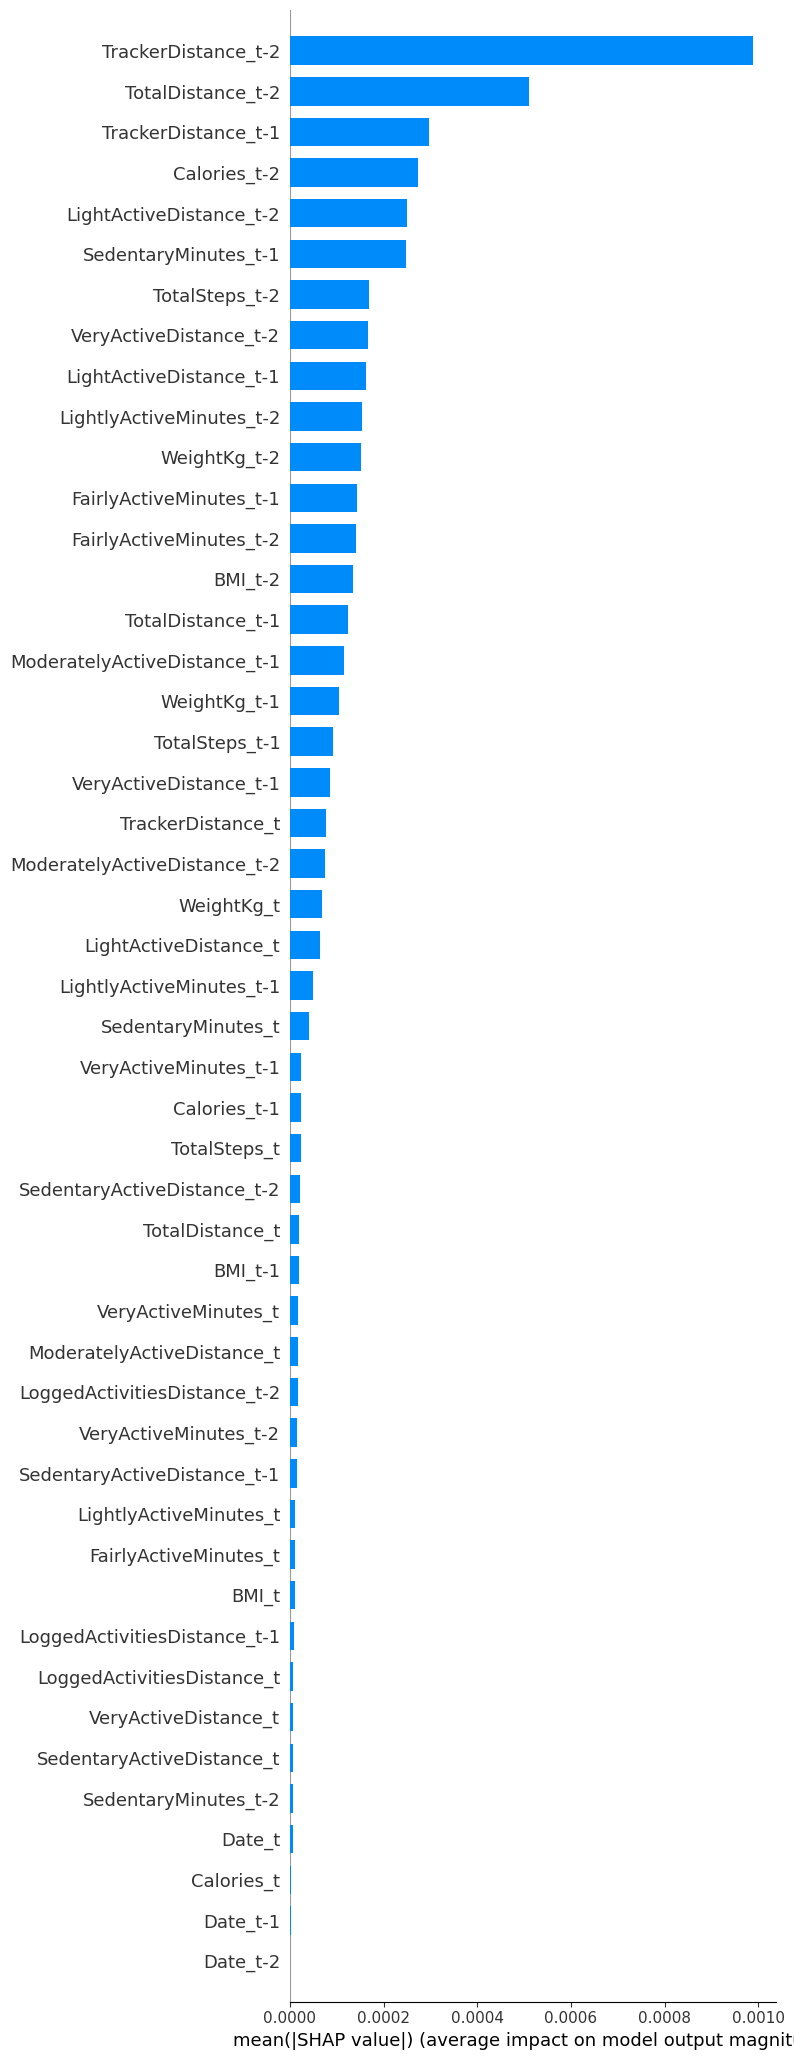

In [4]:
import shap
DE = shap.DeepExplainer(model, trainX) # X_train is 3d numpy.ndarray
shap_values = DE.shap_values(testX, check_additivity=False) # X_validate is 3d numpy.ndarray

shap_val = np.array(shap_values)
shap_val = shap_val.squeeze(axis=0)
shap_val_aux = np.array(shap_values)
testX_aux = np.array(testX)
testX_2d = np.concatenate((testX[:, 0, :], testX[:, 1, :], testX[:, 2, :]), axis=1)
shap_values_2d = np.concatenate((shap_val_aux[0][:, 0, :], shap_val_aux[0][:, 1, :], shap_val_aux[0][:, 2, :]), axis=1)


#reshaped_data = shap_val.reshape((shap_val.shape[0], -1))
#shap_values_2d = shap_values[0][:, 0, :]
shap_t = shap_val[0, :, :]
shap_t = shap_t.reshape(1, -1)
test_graf = testX[0]
test_graf = test_graf.reshape(1, -1)

col_names = list(all_Data.columns)

df_colunas = pd.DataFrame(col_names, columns=['col'])
lag = 3
for i in range(lag):
    for col in col_names:
        if i == 0:
            df_colunas[f"{col}_t"] = df_colunas['col'].shift(i+1)
        else:
            df_colunas[f"{col}_t-{i}"] = df_colunas['col'].shift(i+1)

col_names = df_colunas.iloc[:, 1:].columns.tolist()
print(len(col_names))
print(col_names)
shap.initjs()
shap.summary_plot(
    shap_t, 
    test_graf,
    feature_names=col_names,
    max_display=51,
    plot_type='bar')

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


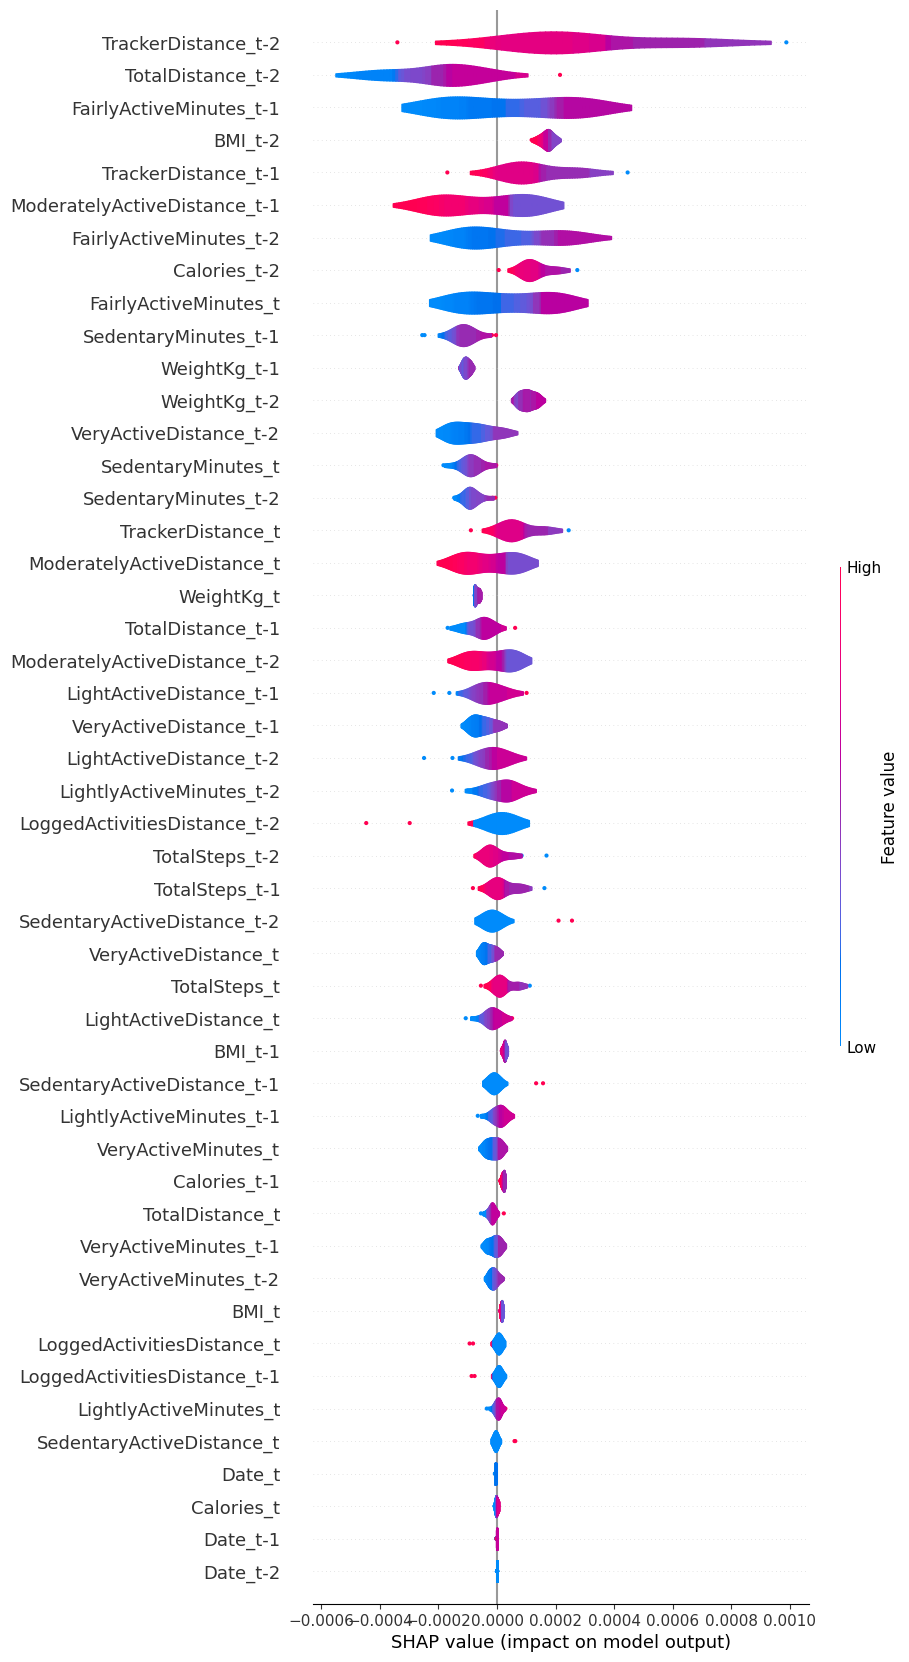

In [5]:
shap.plots.violin(shap_values_2d, feature_names=col_names, features=testX_2d, max_display=51)

In [6]:
transicoes = []
    
for feature_values in shap_values_2d.T:
    indices_transicao = np.where(np.diff(np.sign(feature_values)))[0]
        
    for indice in indices_transicao:
        if feature_values[indice] > 0 and feature_values[indice+1] < 0:
            transicoes.append((indice, feature_values[indice], feature_values[indice+1]))
            
with open('shapvaluesTransition_BMI.csv', 'w', newline='') as arquivo_csv:
    # Criar o objeto de gravação do CSV
    escritor_csv = csv.writer(arquivo_csv)
    
    # Escrever o cabeçalho do CSV
    escritor_csv.writerow(['features', 'min', 'min', 'lim_inf', 'lim_sup'])
    
    for i, transicao in enumerate(transicoes):
            if not (i >= testX_2d.shape[1]):
                feature_num = i + 1
                indice, valor_anterior, valor_posterior = transicao
                valor_feature_anterior = testX_2d[indice, feature_num-1]
                valor_feature_posterior = testX_2d[indice+1, feature_num-1]
                if i == 0 or i == 16 or i == 32:
                    valor_feature_anterior = round(valor_feature_anterior * (date_max - date_min) + date_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (date_max - date_min) + date_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{date_min}] Max: [{date_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {date_min}, {date_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 1 or i == 17 or i == 33:
                    valor_feature_anterior = round(valor_feature_anterior * (totalsteps_max - totalsteps_min) + totalsteps_min,2)
                    valor_feature_posterior = round(valor_feature_posterior * (totalsteps_max - totalsteps_min) + totalsteps_min,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{totalsteps_min}] Max: [{totalsteps_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {totalsteps_min}, {totalsteps_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 2 or i == 18 or i == 34:
                    valor_feature_anterior = round(valor_feature_anterior * (totaldistance_max - totaldistance_min) + totaldistance_min,2)
                    valor_feature_posterior = round(valor_feature_posterior * (totaldistance_max - totaldistance_min) + totaldistance_min,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{totaldistance_min}] Max: [{totaldistance_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {totaldistance_min}, {totaldistance_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 3 or i == 19 or i == 35:
                    valor_feature_anterior = round(valor_feature_anterior * (trackerdistance_max - trackerdistance_min) + trackerdistance_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (trackerdistance_max - trackerdistance_min) + trackerdistance_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{trackerdistance_min}] Max: [{trackerdistance_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {trackerdistance_min}, {trackerdistance_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 4 or i == 20 or i == 36:
                    valor_feature_anterior = round(valor_feature_anterior * (loggedactivitiesdistance_max - loggedactivitiesdistance_min) + loggedactivitiesdistance_min,2)
                    valor_feature_posterior = round(valor_feature_posterior * (loggedactivitiesdistance_max - loggedactivitiesdistance_min) + loggedactivitiesdistance_min,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{loggedactivitiesdistance_min}] Max: [{loggedactivitiesdistance_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {loggedactivitiesdistance_min}, {loggedactivitiesdistance_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 5 or i == 21 or i == 37:
                    valor_feature_anterior = round(valor_feature_anterior * (veryactivedistance_max - veryactivedistance_min) + veryactivedistance_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (veryactivedistance_max - veryactivedistance_min) + veryactivedistance_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{veryactivedistance_min}] Max: [{veryactivedistance_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {veryactivedistance_min}, {veryactivedistance_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 6 or i == 22 or i == 38:
                    valor_feature_anterior = round(valor_feature_anterior * (moderatelyactivedistance_max - moderatelyactivedistance_min) + moderatelyactivedistance_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (moderatelyactivedistance_max - moderatelyactivedistance_min) + moderatelyactivedistance_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{moderatelyactivedistance_min}] Max: [{moderatelyactivedistance_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {moderatelyactivedistance_min}, {moderatelyactivedistance_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 7 or i == 23 or i == 39:
                    valor_feature_anterior = round(valor_feature_anterior * (lightactivedistance_max - lightactivedistance_min) + lightactivedistance_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (lightactivedistance_max - lightactivedistance_min) + lightactivedistance_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{lightactivedistance_min}] Max: [{lightactivedistance_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {lightactivedistance_min}, {lightactivedistance_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 8 or i == 24 or i == 40:
                    valor_feature_anterior = round(valor_feature_anterior * (sedentaryactivedistance_max - sedentaryactivedistance_min) + sedentaryactivedistance_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (sedentaryactivedistance_max - sedentaryactivedistance_min) + sedentaryactivedistance_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{sedentaryactivedistance_min}] Max: [{sedentaryactivedistance_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {sedentaryactivedistance_min}, {sedentaryactivedistance_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 9 or i == 25 or i == 41:
                    valor_feature_anterior = round(valor_feature_anterior * (veryactiveminutes_max - veryactiveminutes_min) + veryactiveminutes_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (veryactiveminutes_max - veryactiveminutes_min) + veryactiveminutes_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{veryactiveminutes_min}] Max: [{veryactiveminutes_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {veryactiveminutes_min}, {veryactiveminutes_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 10 or i == 26 or i == 42:
                    valor_feature_anterior = round(valor_feature_anterior * (fairlyactiveminutes_max - fairlyactiveminutes_min) + fairlyactiveminutes_min,2 )
                    valor_feature_posterior = round(valor_feature_posterior * (fairlyactiveminutes_max - fairlyactiveminutes_min) + fairlyactiveminutes_min,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{fairlyactiveminutes_min}] Max: [{fairlyactiveminutes_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {fairlyactiveminutes_min}, {fairlyactiveminutes_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 11 or i == 27 or i == 43:
                    valor_feature_anterior = round(valor_feature_anterior * (lightlyactiveminutes_max - lightlyactiveminutes_min) + lightlyactiveminutes_min,2)
                    valor_feature_posterior = round(valor_feature_posterior * (lightlyactiveminutes_max - lightlyactiveminutes_min) + lightlyactiveminutes_min,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{lightlyactiveminutes_min}] Max: [{lightlyactiveminutes_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {lightlyactiveminutes_min}, {lightlyactiveminutes_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 12 or i == 28 or i == 44:
                    valor_feature_anterior = round(valor_feature_anterior * (sedentaryminutes_max - sedentaryminutes_min) + sedentaryminutes_min,2)
                    valor_feature_posterior = round(valor_feature_posterior * (sedentaryminutes_max - sedentaryminutes_min) + sedentaryminutes_min,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{sedentaryminutes_min}] Max: [{sedentaryminutes_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {sedentaryminutes_min}, {sedentaryminutes_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 13 or i == 29 or i == 45:
                    valor_feature_anterior = round(valor_feature_anterior * (calories_max - calories_min) + calories_min,2)
                    valor_feature_posterior = round(valor_feature_posterior * (calories_max - calories_min) + calories_min,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{calories_min}] Max: [{calories_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {calories_min}, {calories_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 14 or i == 30 or i == 46:
                    valor_feature_anterior = round(valor_feature_anterior * (weightkg_max - weightkg_min) + weightkg_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (weightkg_max - weightkg_min) + weightkg_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{weightkg_min}] Max: [{weightkg_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {weightkg_min}, {weightkg_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 15 or i == 31 or i == 47:
                    valor_feature_anterior = round(valor_feature_anterior * (bmi_max - bmi_min) + bmi_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (bmi_max - bmi_min) + bmi_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{bmi_min}] Max: [{bmi_max}] ")
                    escritor_csv.writerow([f"{col_names[i]}, {bmi_min}, {bmi_max}, {valor_feature_anterior}, {valor_feature_posterior}"])

Date_t: [2.0, 2.0] -> Min: [0] Max: [30]
TotalSteps_t: [10742.0, 13928.0] -> Min: [29] Max: [29326]
TotalDistance_t: [7.09, 13.24] -> Min: [0.02] Max: [26.72]
TrackerDistance_t: [3.32, 9.08] -> Min: [0.02] Max: [26.72]
LoggedActivitiesDistance_t: [0.0, 0.0] -> Min: [0.0] Max: [4.08]
VeryActiveDistance_t: [0.0, 1.2] -> Min: [0.0] Max: [21.66]
ModeratelyActiveDistance_t: [2.0, 0.0] -> Min: [0.0] Max: [2.39]
LightActiveDistance_t: [2.87, 5.09] -> Min: [0.02] Max: [10.71]
SedentaryActiveDistance_t: [0.0, 0.0] -> Min: [0.0] Max: [0.11]
VeryActiveMinutes_t: [48.0, 53.0] -> Min: [0] Max: [200]
FairlyActiveMinutes_t: [0.0, 31.0] -> Min: [0] Max: [42]
LightlyActiveMinutes_t: [214.0, 240.0] -> Min: [3] Max: [429]
SedentaryMinutes_t: [484.0, 720.0] -> Min: [127] Max: [1363]
Calories_t: [2027.0, 2039.0] -> Min: [928] Max: [4552]
WeightKg_t: [61.7, 61.4] -> Min: [52.6] Max: [90.7]
BMI_t: [24.0, 24.1] -> Min: [21.45] Max: [28.0] 
Date_t-1: [1.0, 1.0] -> Min: [0] Max: [30]
TotalSteps_t-1: [10081.0, 5